# Classification

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

KORS_PATH    = Path('../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx')
RAK_PATH     = Path('../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx')
FEATURES_DIR = Path('../data/processed/features')
SELECTED_DIR = FEATURES_DIR / 'combined/per_video'
OUT_DIR      = Path('../data/processed/classification')
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHASE_MAP = {
    'iraf_utg':   'selected_features_utg.csv',
    'iraf_forb':  'selected_features_forb.csv',
    'iraf_uppr':  'selected_features_uppr.csv',
    'iraf_total': 'selected_features_total.csv',
}

## Load IRAF Scores

In [2]:
def parse_iraf_per_video(xl, sheet_name, phase_map, fp_videos=None):
    _UNSET = object()
    def match_phase(text):
        for prefix, label in phase_map:
            if text.startswith(prefix):
                return label
        return _UNSET

    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].fillna('').astype(str)

    is_block = col0.str.contains('Film Nr', na=False) | col0.str.contains(', [Vv]ideo ', na=False, regex=True)
    if fp_videos is not None:
        is_block = is_block | col0.str.match(r'Fp\d+_', na=False)
    block_rows = raw.index[is_block].tolist()
    block_rows.append(len(raw))

    def get_video(text):
        if 'Film Nr' in text:
            return text.split('Film Nr:')[1].strip().split()[0].zfill(3)
        elif ', video ' in text.lower():
            return text.lower().split(', video ')[1].strip().split()[0].zfill(3)
        elif fp_videos is not None:
            m = re.match(r'Fp(\d+)_', text)
            if m:
                idx = int(m.group(1)) - 1
                return fp_videos[idx] if idx < len(fp_videos) else None
        return None

    records = []
    for i, start in enumerate(block_rows[:-1]):
        video = get_video(col0.iloc[start])
        if video is None:
            continue
        block = raw.iloc[start:block_rows[i+1]]
        current_phase = _UNSET
        for row_idx in block.index:
            cell_text = str(raw.iloc[row_idx, 0]).strip()
            matched = match_phase(cell_text)
            if matched is not _UNSET:
                current_phase = matched
                continue
            if current_phase is _UNSET or current_phase is None:
                continue
            gem = raw.iloc[row_idx, 12]
            weight = pd.to_numeric(raw.iloc[row_idx, 1], errors='coerce')
            if pd.notna(weight) and pd.notna(gem):
                try:
                    records.append({'video': video, 'phase': current_phase,
                                    'weight': weight, 'avvikelse': float(gem)})
                except ValueError:
                    pass
    return pd.DataFrame(records)

UP_PHASE_MAP = [
    ('Utgångsposition',  'utg'),
    ('Rörelsestart',     None),
    ('Rörelseutförande', None),
    ('Förberedelsefas',  'forb'),
    ('Uppresningsfas',   'uppr'),
]

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df = parse_iraf_per_video(kors_xl, 'Sittande till stående', UP_PHASE_MAP)
rak_df  = parse_iraf_per_video(rak_xl,  'Sittande till stående', UP_PHASE_MAP)
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

iraf_pv = iraf_raw.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

phase_score_cols = [c for c in iraf_pv.columns if c != 'video']
iraf_pv['iraf_total'] = iraf_pv[phase_score_cols].mean(axis=1)

iraf_pv

,video,iraf_forb,iraf_uppr,iraf_utg,iraf_total
0,028,0.833333,0.875000,0.870370,0.859568
1,030,0.333333,0.250000,0.055556,0.212963
2,045,1.000000,1.500000,1.407407,1.302469
3,047,0.833333,0.750000,1.523810,1.035714
4,059,0.833333,0.833333,0.937500,0.868056
5,061,0.833333,0.750000,0.650000,0.744444
6,074,0.944444,1.125000,1.047619,1.039021
7,076,0.500000,1.500000,0.555556,0.851852
8,091,0.583333,1.250000,1.460317,1.097884
9,093,0.500000,0.625000,0.722222,0.615741


## Transform target to binary labels
Target: IRAF score 
- 0 (no deviation): score `<= 0.5`  
- 1 (deviation): score `> 0.5`

In [3]:
def to_binary(score):
    if score <= 0.5:
        return 0
    elif score > 0.5:
        return 1
    return np.nan

iraf_bin = iraf_pv.copy()
for col in ['iraf_utg', 'iraf_forb', 'iraf_uppr', 'iraf_total']:
    iraf_bin[col] = iraf_bin[col].apply(to_binary)

iraf_bin['video'] = iraf_bin['video'].astype(str).str[-3:]
print(iraf_bin.to_string())

  video  iraf_forb  iraf_uppr  iraf_utg  iraf_total
0   028          1          1         1           1
1   030          0          0         0           0
2   045          1          1         1           1
3   047          1          1         1           1
4   059          1          1         1           1
5   061          1          1         1           1
6   074          1          1         1           1
7   076          0          1         1           1
8   091          1          1         1           1
9   093          0          1         1           1


Binary target:
- `0` if score `<= 0.5`
- `1` if score `> 0.5`
- no gray zone is excluded

## Load features per phase

In [4]:
pose_all = (
    pd.read_csv(FEATURES_DIR / 'utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'förberedelsefas.csv'), on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'uppresningsfas.csv'),  on='video')
)
molab_all = (
    pd.read_csv(FEATURES_DIR / 'molab_utgångsposition.csv')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_förberedelsefas.csv'), on='video')
    .merge(pd.read_csv(FEATURES_DIR / 'molab_uppresningsfas.csv'),  on='video')
)

pose_all['video']  = pose_all['video'].astype(str).str.zfill(3)
molab_all['video'] = molab_all['video'].astype(str).str.zfill(3)

pose_cols  = {c: f'pose_{c}'  for c in pose_all.columns  if c != 'video'}
molab_cols = {c: f'molab_{c}' for c in molab_all.columns if c != 'video'}
pose_all   = pose_all.rename(columns=pose_cols)
molab_all  = molab_all.rename(columns=molab_cols)

iraf_bin['video'] = iraf_bin['video'].astype(str).str[-3:]

phase_dfs = {}
for target, fname in PHASE_MAP.items():
    sel         = pd.read_csv(SELECTED_DIR / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature']]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature']]
    short       = target.replace('iraf_', '')
    pose_df     = pose_all[['video'] + pose_feats]
    molab_df    = molab_all[['video'] + molab_feats]
    phase_dfs[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        iraf_bin[['video', target]].dropna(subset=[target]),
    }

for phase, sources in phase_dfs.items():
    print(f"\n{phase}:")
    for source, val in sources.items():
        if source == 'y':
            labels = val.iloc[:, 1].astype(int).tolist()
            print(f"  y: {labels}")
        else:
            print(f"  {source}: {val.shape}  {val.columns[1:].tolist()}")


utg:
  pose: (10, 4)  ['pose_forb_mean_trunk_angular_velocity', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_hip_forward_displacement']
  molab: (10, 4)  ['molab_utg_mean_R_knee_flexion', 'molab_forb_peak_pelvis_gyro', 'molab_forb_mean_pelvis_gyro']
  combined: (10, 7)  ['pose_forb_mean_trunk_angular_velocity', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_hip_forward_displacement', 'molab_utg_mean_R_knee_flexion', 'molab_forb_peak_pelvis_gyro', 'molab_forb_mean_pelvis_gyro']
  y: [1, 0, 1, 1, 1, 1, 1, 1, 1, 1]

forb:
  pose: (10, 4)  ['pose_uppr_hip_forward_displacement', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_trunk_reextension_angle']
  molab: (10, 4)  ['molab_uppr_total_hip_extension', 'molab_uppr_total_knee_extension', 'molab_forb_peak_pelvis_gyro']
  combined: (10, 7)  ['pose_uppr_hip_forward_displacement', 'pose_uppr_trunk_hip_correlation', 'pose_uppr_trunk_reextension_angle', 'molab_uppr_total_hip_extension', 'molab_uppr_total_knee_extension', 'molab_forb_peak_pelvis_gy

## Classification: LOOCV

`n = 10`
LOOCV runs `n` iterations:
- `n-1` videos for training 
- `1` video for testing 

So every video is used once as the test sample


### Models: 
- **Logistic Regression**
- **Random Forest**
- **XGBoost**  


In [5]:
MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=30, max_depth=2, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=30, max_depth=2, learning_rate=0.1,
        eval_metric='logloss', random_state=42, verbosity=0
    ),
}

FEATURE_SETS = ['pose', 'molab', 'combined']
MODEL_ORDER  = list(MODELS.keys())
TARGET_COL   = 'iraf_'

loo = LeaveOneOut()
loocv_results = []

for phase, data in phase_dfs.items():
    target  = TARGET_COL + phase
    y_df    = data['y']
    videos  = y_df['video'].values
    y_all   = y_df[target].values.astype(int)
    for fs in FEATURE_SETS:
        merged = data[fs].merge(y_df[['video']], on='video')
        X      = merged.drop(columns='video').values
        for model_name, model in MODELS.items():
            y_true, y_pred, y_prob, vid_out = [], [], [], []
            for train_idx, test_idx in loo.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train = y_all[train_idx]
                if len(np.unique(y_train)) < 2:
                    continue
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)
                m = clone(model)
                m.fit(X_train, y_train)
                y_true.append(y_all[test_idx][0])
                y_pred.append(m.predict(X_test)[0])
                prob    = m.predict_proba(X_test)[0]
                pos_idx = list(m.classes_).index(1) if 1 in m.classes_ else 0
                y_prob.append(prob[pos_idx])
                vid_out.append(videos[test_idx][0])
            loocv_results.append({
                'phase':       phase,
                'model':       model_name,
                'feature_set': fs,
                'videos':      vid_out,
                'y_true':      y_true,
                'y_pred':      y_pred,
                'y_prob':      y_prob,
            })

print(f'Completed: {len(loocv_results)} models trained')


Completed: 36 models trained


- `4`phases
- `3`feature sets 
- `3` models

So `36`model configurations were trained in total

## Evaluation

In [6]:
rows = []
for r in loocv_results:
    yt, yp, ypr = r['y_true'], r['y_pred'], r['y_prob']
    n_classes = len(set(yt))
    rows.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'Accuracy':    accuracy_score(yt, yp),
        'F1':          f1_score(yt, yp, zero_division=np.nan),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'AUC':         roc_auc_score(yt, ypr) if n_classes > 1 else np.nan,
    })

eval_df = pd.DataFrame(rows)
eval_df.to_csv(OUT_DIR / 'classification_results.csv', index=False)

METRICS = ['Accuracy', 'F1', 'AUC']

for phase in eval_df['phase'].unique():
    print(f"\nPhase: {phase}")
    sub   = eval_df[eval_df['phase'] == phase].copy()
    table = sub.pivot_table(index='model', columns='feature_set', values=METRICS).round(3)
    table.columns = [f'{metric}_{fs}' for metric, fs in table.columns]
    print(table.to_string())
    print()


Phase: utg
                    Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose
model                                                                                               
LogisticRegression                1.0             1.0            1.0          1.0       1.0      1.0
RandomForest                      1.0             1.0            1.0          1.0       1.0      1.0
XGBoost                           1.0             1.0            1.0          1.0       1.0      1.0


Phase: forb
                    AUC_combined  AUC_molab  AUC_pose  Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose
model                                                                                                                                  
LogisticRegression         0.857      0.905     0.476                0.8             0.8            0.5        0.857     0.857    0.667
RandomForest               0.810      0.905     0.286        

- `Utgångsposition`, `Rörelsestart`, and `Total` are almost perfectly classified
- `Rörelseutförande` is the hardest phase
- `LogisticRegression + Combined` performs best in `Rörelseutförande`

## McNemar test: compare models pairwise

In [7]:
mcnemar_rows = []

model_pairs = [
    ('LogisticRegression', 'RandomForest'),
    ('LogisticRegression', 'XGBoost'),
    ('RandomForest',       'XGBoost'),
]

for phase in eval_df['phase'].unique():
    for fs in FEATURE_SETS:
        for m1, m2 in model_pairs:
            r1 = next(r for r in loocv_results
                      if r['phase'] == phase and r['model'] == m1 and r['feature_set'] == fs)
            r2 = next(r for r in loocv_results
                      if r['phase'] == phase and r['model'] == m2 and r['feature_set'] == fs)
            yt = np.array(r1['y_true'])
            p1 = np.array(r1['y_pred'])
            p2 = np.array(r2['y_pred'])
            b = np.sum((p1 == yt) & (p2 != yt))
            c = np.sum((p1 != yt) & (p2 == yt))
            table = [[np.sum((p1 == yt) & (p2 == yt)), b],
                     [c, np.sum((p1 != yt) & (p2 != yt))]]
            result = mcnemar(table, exact=True)
            mcnemar_rows.append({
                'phase':       phase,
                'feature_set': fs,
                'model_1':     m1,
                'model_2':     m2,
                'b':           b,
                'c':           c,
                'p_value':     result.pvalue,
                'significant': result.pvalue < 0.05,
            })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(OUT_DIR / 'mcnemar_results.csv', index=False)

print(mcnemar_df[['phase','feature_set','model_1','model_2','p_value','significant']].to_string(index=False))


phase feature_set            model_1      model_2  p_value  significant
  utg        pose LogisticRegression RandomForest    1.000        False
  utg        pose LogisticRegression      XGBoost    1.000        False
  utg        pose       RandomForest      XGBoost    1.000        False
  utg       molab LogisticRegression RandomForest    1.000        False
  utg       molab LogisticRegression      XGBoost    1.000        False
  utg       molab       RandomForest      XGBoost    1.000        False
  utg    combined LogisticRegression RandomForest    1.000        False
  utg    combined LogisticRegression      XGBoost    1.000        False
  utg    combined       RandomForest      XGBoost    1.000        False
 forb        pose LogisticRegression RandomForest    0.500        False
 forb        pose LogisticRegression      XGBoost    0.500        False
 forb        pose       RandomForest      XGBoost    0.125        False
 forb       molab LogisticRegression RandomForest    1.000      

McNemar test:
- all `p > 0.05`
- no pairwise comparison is statistically significant

**So the observed difference may be due to the small dataset**



## Visualisation: metrics per phase

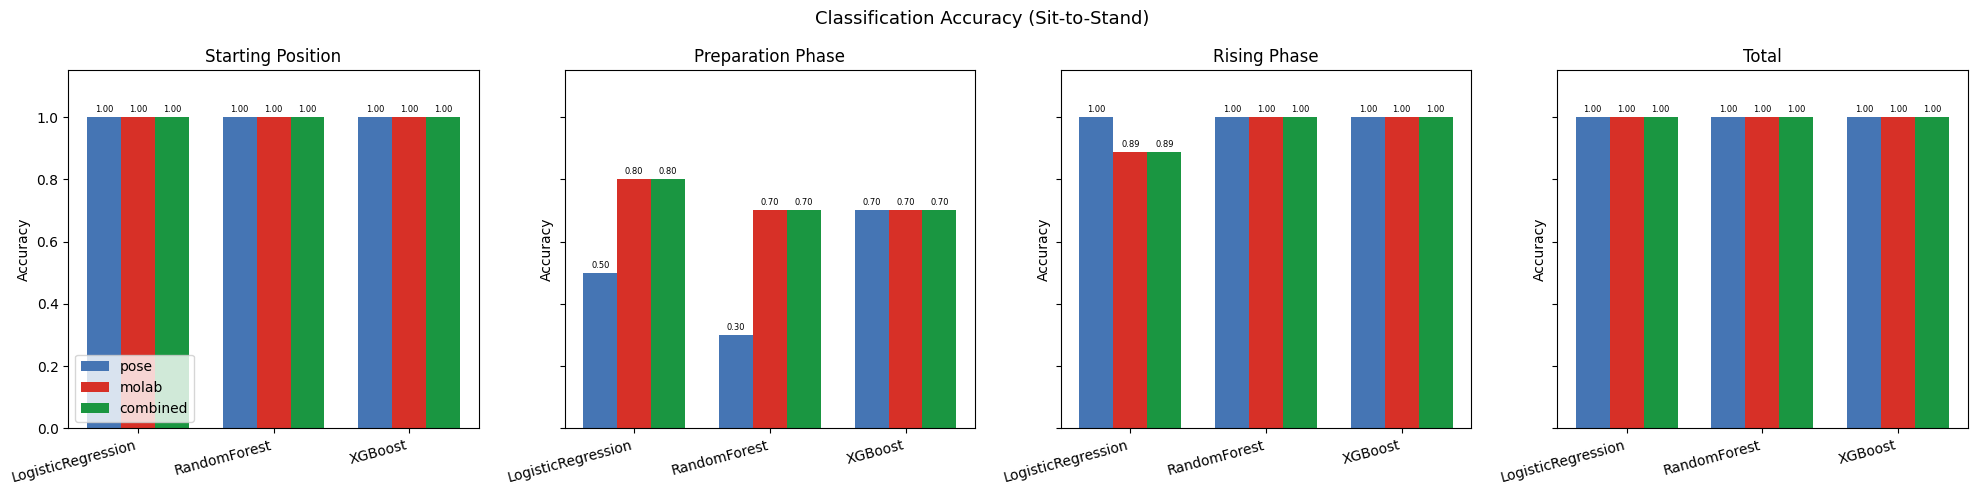

Saved: classification_accuracy_bar.png


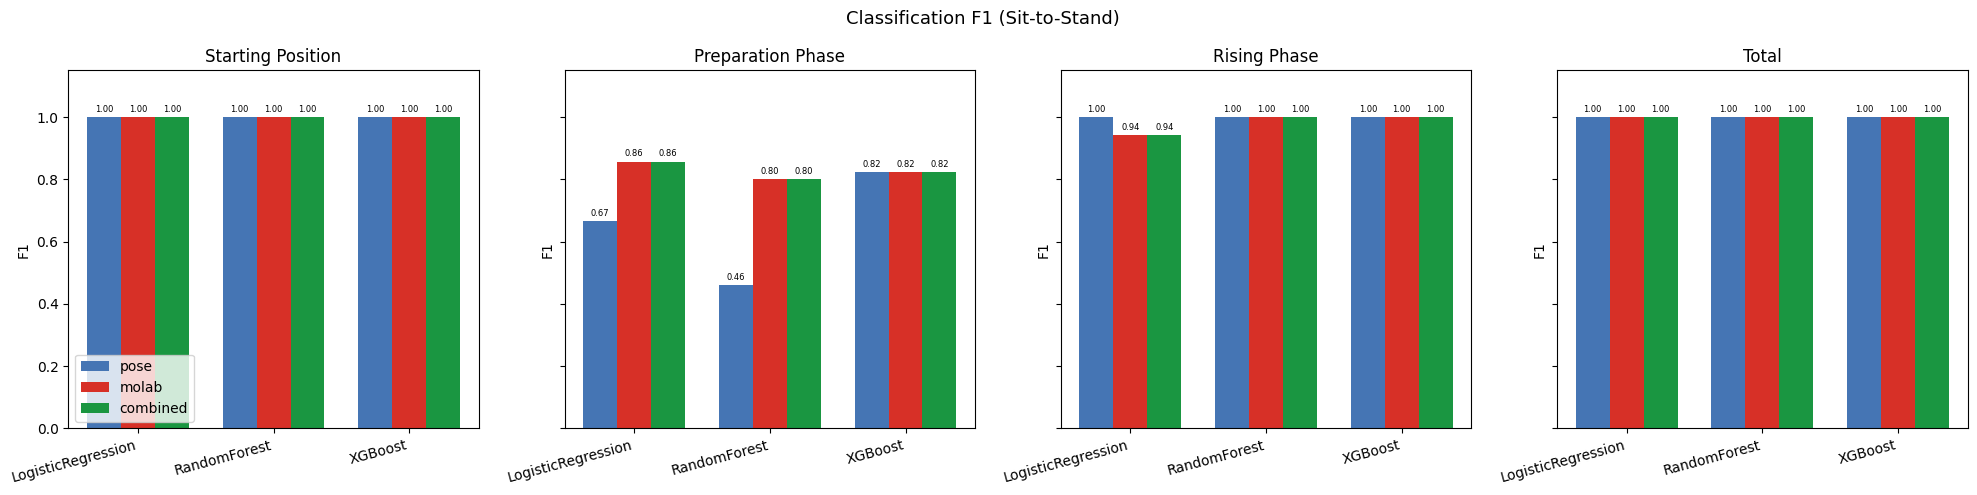

Saved: classification_f1_bar.png


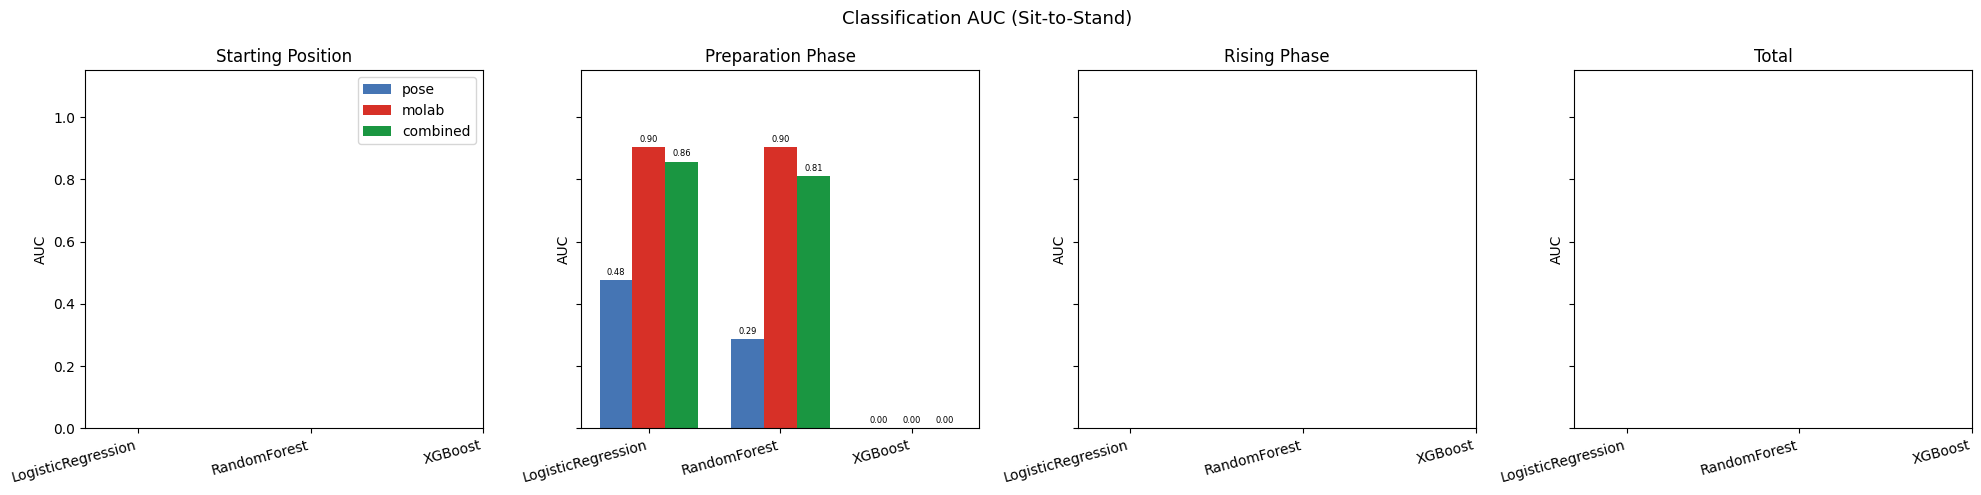

Saved: classification_auc_bar.png


In [8]:
PHASE_LABELS = {
    'utg':   'Starting Position',
    'forb':  'Preparation Phase',
    'uppr':  'Rising Phase',
    'total': 'Total',
}

COLORS = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}
PHASE_ORDER = ['utg', 'forb', 'uppr', 'total']

for metric in ['Accuracy', 'F1', 'AUC']:
    fig, axes = plt.subplots(1, len(PHASE_ORDER), figsize=(20, 5), sharey=True)
    fig.suptitle(f'Classification {metric} (Sit-to-Stand)', fontsize=13)
    for ax, phase in zip(axes, PHASE_ORDER):
        sub = eval_df[eval_df['phase'] == phase]
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = []
            for m in MODEL_ORDER:
                mask = (sub['model'] == m) & (sub['feature_set'] == fs)
                v    = sub[mask][metric].values
                vals.append(v[0] if len(v) else np.nan)
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS[fs])
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}',
                        ha='center', va='bottom', fontsize=6
                    )
        ax.set_title(PHASE_LABELS[phase])
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'classification_{metric.lower()}_bar.png', dpi=150)
    plt.show()
    print(f'Saved: classification_{metric.lower()}_bar.png')


- `Rörelseutförande` shows the clearest separation between models
- The clearest benefit of `Combined` features appears in `Rörelseutförande`.

## Champion model per phase

In [9]:
METRICS = ['Accuracy', 'F1', 'AUC']

champion_rows = []
for phase in eval_df['phase'].unique():
    for fs in FEATURE_SETS:
        sub  = eval_df[(eval_df['phase'] == phase) & (eval_df['feature_set'] == fs)]
        # Fall back to Accuracy if AUC is all NaN
        if sub['AUC'].notna().any():
            best = sub.loc[sub['AUC'].idxmax()]
        else:
            best = sub.loc[sub['Accuracy'].idxmax()]
        champion_rows.append({
            'phase':       phase,
            'feature_set': fs,
            'model':       best['model'],
            'Accuracy':    round(best['Accuracy'], 3),
            'F1':          round(best['F1'],       3),
            'AUC':         round(best['AUC'], 3) if pd.notna(best['AUC']) else float('nan'),
        })

champion_df = pd.DataFrame(champion_rows)
champion_df.to_csv(OUT_DIR / 'champion_models.csv', index=False)
print(champion_df.to_string(index=False))


phase feature_set              model  Accuracy    F1   AUC
  utg        pose LogisticRegression       1.0 1.000   NaN
  utg       molab LogisticRegression       1.0 1.000   NaN
  utg    combined LogisticRegression       1.0 1.000   NaN
 forb        pose LogisticRegression       0.5 0.667 0.476
 forb       molab LogisticRegression       0.8 0.857 0.905
 forb    combined LogisticRegression       0.8 0.857 0.857
 uppr        pose LogisticRegression       1.0 1.000   NaN
 uppr       molab       RandomForest       1.0 1.000   NaN
 uppr    combined       RandomForest       1.0 1.000   NaN
total        pose LogisticRegression       1.0 1.000   NaN
total       molab LogisticRegression       1.0 1.000   NaN
total    combined LogisticRegression       1.0 1.000   NaN


- `LogisticRegression` is best in `12 / 12` phase-feature combinations

## Per-video error comparison: Pose vs MoLab

In [10]:
rows = []
for r in loocv_results:
    for vid, yt, yp in zip(r['videos'], r['y_true'], r['y_pred']):
        rows.append({
            'phase':       r['phase'],
            'model':       r['model'],
            'feature_set': r['feature_set'],
            'video':       vid,
            'y_true':      yt,
            'y_pred':      yp,
        })

per_video_df = pd.DataFrame(rows)
per_video_df.to_csv(OUT_DIR / 'per_video_predictions.csv', index=False)

for phase in eval_df['phase'].unique():
    print(f"\n{'='*65}")
    print(f" Phase: {phase}")
    print(f"{'='*65}")
    for model in MODEL_ORDER:
        sub   = per_video_df[(per_video_df['phase'] == phase) & (per_video_df['model'] == model)]
        pose  = sub[sub['feature_set'] == 'pose'].set_index('video')[['y_true','y_pred']].rename(columns={'y_pred':'pose_pred'})
        molab = sub[sub['feature_set'] == 'molab'][['video','y_pred']].set_index('video').rename(columns={'y_pred':'molab_pred'})

        compare = pose.join(molab)
        compare['pose_error']  = compare['y_true'] != compare['pose_pred']
        compare['molab_error'] = compare['y_true'] != compare['molab_pred']

        diff = compare[compare['pose_error'] != compare['molab_error']]
        if diff.empty:
            continue

        print(f"\n  Model: {model}")
        print(f"  {'-'*55}")
        print(f"  {'Video':<8} {'True':>6} {'Pose':>8} {'MoLab':>8} {'Pose err':>10} {'MoLab err':>10}")
        print(f"  {'-'*55}")
        for vid, row in diff.iterrows():
            pose_err  = 'FP' if (row.pose_error  and row.pose_pred  > row.y_true) else ('FN' if row.pose_error  else '-')
            molab_err = 'FP' if (row.molab_error and row.molab_pred > row.y_true) else ('FN' if row.molab_error else '-')
            print(f"  {str(vid):<8} {int(row.y_true):>6} {int(row.pose_pred):>8} {int(row.molab_pred):>8} {pose_err:>10} {molab_err:>10}")
        print(f"  {'-'*55}")



 Phase: utg

 Phase: forb

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  030           0        1        0         FP          -
  061           1        0        1         FN          -
  093           0        1        0         FP          -
  -------------------------------------------------------

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  028           1        0        1         FN          -
  059           1        0        1         FN          -
  061           1        0        1         FN          -
  093           0        1        0         FP          -
  -------------------------------------------------------

 Phase: uppr

  Model: LogisticRegression
  ------

Error comparison:
- most disagreements are isolated false negatives
- `Pose` misses videos `047` and `061` in `Rörelseutförande`
- `MoLab` also misses a few positives, such as `076` and `093`

So the errors are limited, but they are concentrated in a few videos.

## Stående till sittande (Stand-to-Sit)

In [11]:
OUT_DIR_DOWN_CLS = Path('../data/processed/classification_down')
OUT_DIR_DOWN_CLS.mkdir(parents=True, exist_ok=True)

DOWN_FEATURES_DIR_CLS = Path('../data/processed/features_down')
DOWN_SELECTED_DIR_CLS = DOWN_FEATURES_DIR_CLS / 'combined/per_video'

DOWN_PHASE_MAP_CLS = [
    ('Utgångsposition',  'utg'),
    ('Rörelsestart',     None),
    ('Rörelseutförande', None),
    ('Fas 1',            'ned'),
    ('Fas 2',            'bak'),
]

PHASE_MAP_DOWN_CLS = {
    'iraf_utg':   'selected_features_utg.csv',
    'iraf_ned':   'selected_features_ned.csv',
    'iraf_bak':   'selected_features_bak.csv',
    'iraf_total': 'selected_features_total.csv',
}

RAK_DOWN_FP_VIDEOS_CLS = ['030', '047', '061', '076', '093']

kors_df_d = parse_iraf_per_video(kors_xl, 'Stående till sittande', DOWN_PHASE_MAP_CLS)
rak_df_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', DOWN_PHASE_MAP_CLS, fp_videos=RAK_DOWN_FP_VIDEOS_CLS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

iraf_pv_d = iraf_raw_d.groupby(['video', 'phase']).apply(
    lambda g: g['w'].sum() / g['weight'].sum()
).unstack().reset_index()
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

phase_score_cols_d = [c for c in iraf_pv_d.columns if c != 'video']
iraf_pv_d['iraf_total'] = iraf_pv_d[phase_score_cols_d].mean(axis=1)

iraf_bin_d = iraf_pv_d.copy()
for col in [c for c in iraf_bin_d.columns if c.startswith('iraf_')]:
    iraf_bin_d[col] = iraf_bin_d[col].apply(to_binary)
iraf_bin_d['video'] = iraf_bin_d['video'].astype(str).str.zfill(3)

iraf_bin_d

,video,iraf_bak,iraf_ned,iraf_utg,iraf_total
0,028,1,0,0,1
1,030,0,0,0,0
2,045,1,0,1,1
3,047,1,0,1,1
4,059,1,0,1,1
5,061,1,0,1,1
6,074,1,0,0,1
7,076,1,0,1,1
8,091,1,0,1,1
9,093,1,1,1,1


In [12]:
pose_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_nedåtgående.csv'),  on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_bakåtgående.csv'),  on='video')
)
molab_all_d = (
    pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_utgångsposition.csv')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_nedåtgående.csv'),  on='video')
    .merge(pd.read_csv(DOWN_FEATURES_DIR_CLS / 'down_molab_bakåtgående.csv'),  on='video')
)

pose_all_d['video']  = pose_all_d['video'].astype(str).str.zfill(3)
molab_all_d['video'] = molab_all_d['video'].astype(str).str.zfill(3)
pose_all_d  = pose_all_d.rename(columns={c: f'pose_{c}'  for c in pose_all_d.columns  if c != 'video'})
molab_all_d = molab_all_d.rename(columns={c: f'molab_{c}' for c in molab_all_d.columns if c != 'video'})

phase_dfs_down_cls = {}
for target, fname in PHASE_MAP_DOWN_CLS.items():
    sel = pd.read_csv(DOWN_SELECTED_DIR_CLS / fname)
    pose_feats  = [f'pose_{f}'  for f in sel[sel['source'] == 'Pose']['feature'].tolist()]
    molab_feats = [f'molab_{f}' for f in sel[sel['source'] == 'MoLab']['feature'].tolist()]
    short = target.replace('iraf_', '')

    y_df = iraf_bin_d[['video', target]].dropna()

    pose_df  = pose_all_d[['video'] + pose_feats].merge(y_df[['video']], on='video')
    molab_df = molab_all_d[['video'] + molab_feats].merge(y_df[['video']], on='video')

    phase_dfs_down_cls[short] = {
        'pose':     pose_df,
        'molab':    molab_df,
        'combined': pose_df.merge(molab_df, on='video'),
        'y':        y_df,
    }

for phase, sources in phase_dfs_down_cls.items():
    print(f"\n{phase}: n={len(sources['y'])}, labels={sources['y'].iloc[:,1].value_counts().to_dict()}")


utg: n=10, labels={1: 7, 0: 3}

ned: n=10, labels={0: 9, 1: 1}

bak: n=10, labels={1: 9, 0: 1}

total: n=10, labels={1: 9, 0: 1}


Sample size:
- all phases now use `n = 10` videos
- no videos are excluded by a gray zone
- label balance still differs between phases

So the phase comparisons are now more direct than before.

In [13]:
loocv_results_down_cls = []

for phase, data in phase_dfs_down_cls.items():
    target  = 'iraf_' + phase
    y_df    = data['y']
    videos_d  = y_df['video'].values
    y_all   = y_df[target].values.astype(int)
    for fs in FEATURE_SETS:
        merged = data[fs].merge(y_df[['video']], on='video')
        X      = merged.drop(columns='video').values
        for model_name, model in MODELS.items():
            y_true, y_pred, y_prob, vid_out = [], [], [], []
            for train_idx, test_idx in loo.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train = y_all[train_idx]
                if len(np.unique(y_train)) < 2:
                    continue
                scaler  = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)
                m = clone(model)
                m.fit(X_train, y_train)
                y_true.append(y_all[test_idx][0])
                y_pred.append(m.predict(X_test)[0])
                prob    = m.predict_proba(X_test)[0]
                pos_idx = list(m.classes_).index(1) if 1 in m.classes_ else 0
                y_prob.append(prob[pos_idx])
                vid_out.append(videos_d[test_idx][0])
            loocv_results_down_cls.append({
                'phase':       phase,
                'model':       model_name,
                'feature_set': fs,
                'videos':      vid_out,
                'y_true':      y_true,
                'y_pred':      y_pred,
                'y_prob':      y_prob,
            })

print(f'Completed: {len(loocv_results_down_cls)} models trained')


Completed: 36 models trained


LOOCV finished:
- `36 = 4 × 3 × 3`
- `4` phases
- `3` feature sets
- `3` models

So all stand-to-sit model configurations were trained.

In [14]:
rows_d = []
for r in loocv_results_down_cls:
    yt, yp, ypr = r['y_true'], r['y_pred'], r['y_prob']
    n_classes = len(set(yt))
    rows_d.append({
        'phase':       r['phase'],
        'model':       r['model'],
        'feature_set': r['feature_set'],
        'Accuracy':    accuracy_score(yt, yp),
        'F1':          f1_score(yt, yp, zero_division=np.nan),
        'Precision':   precision_score(yt, yp, zero_division=0),
        'Recall':      recall_score(yt, yp, zero_division=0),
        'AUC':         roc_auc_score(yt, ypr) if n_classes > 1 else np.nan,
    })

eval_df_down_cls = pd.DataFrame(rows_d)
eval_df_down_cls.to_csv(OUT_DIR_DOWN_CLS / 'classification_results.csv', index=False)

METRICS_D = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']

for phase in eval_df_down_cls['phase'].unique():
    print(f"\nPhase: {phase}")
    sub   = eval_df_down_cls[eval_df_down_cls['phase'] == phase].copy()
    table = sub.pivot_table(index='model', columns='feature_set', values=METRICS_D).round(3)
    table.columns = [f'{metric}_{fs}' for metric, fs in table.columns]
    print(table.to_string())
    print()


Phase: utg
                    AUC_combined  AUC_molab  AUC_pose  Accuracy_combined  Accuracy_molab  Accuracy_pose  F1_combined  F1_molab  F1_pose  Precision_combined  Precision_molab  Precision_pose  Recall_combined  Recall_molab  Recall_pose
model                                                                                                                                                                                                                                   
LogisticRegression         0.619      0.619     0.714                0.6             0.5            0.7        0.714     0.667    0.800               0.714            0.625           0.750            0.714         0.714        0.857
RandomForest               0.619      0.524     0.690                0.6             0.5            0.6        0.750     0.667    0.750               0.667            0.625           0.667            0.857         0.714        0.857
XGBoost                    0.000      0.000     0.000   

- `LogisticRegression` performs best in most phase-feature combinations
- `Total` reaches the highest scores, especially for `Pose` and `Combined`
- `XGBoost` remains unstable despite moderate accuracy in some phases

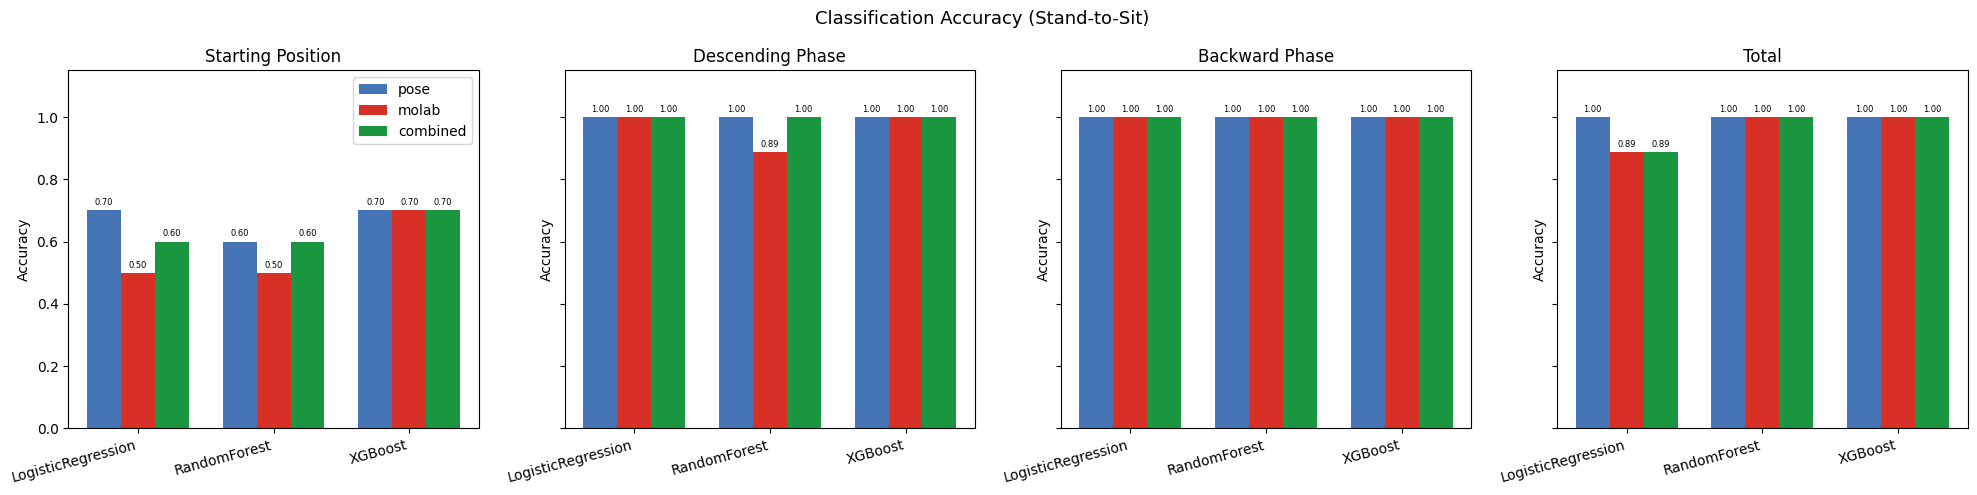

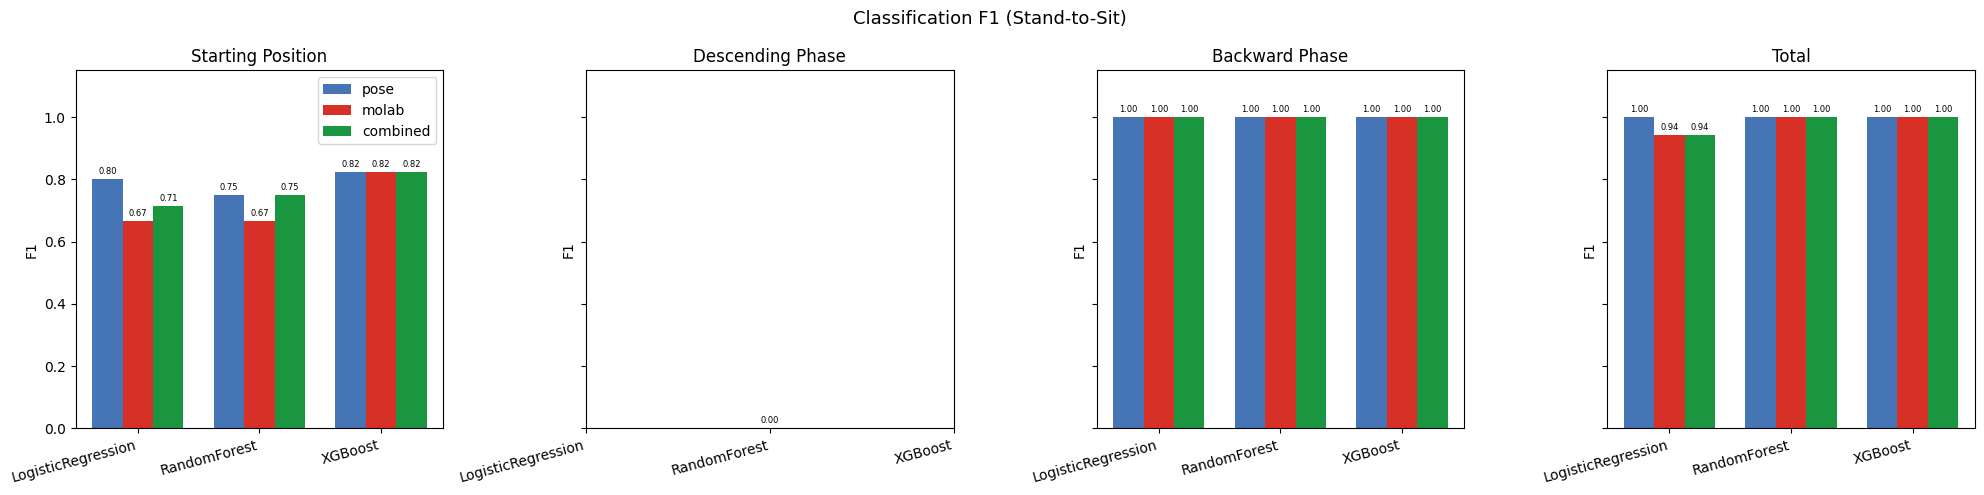

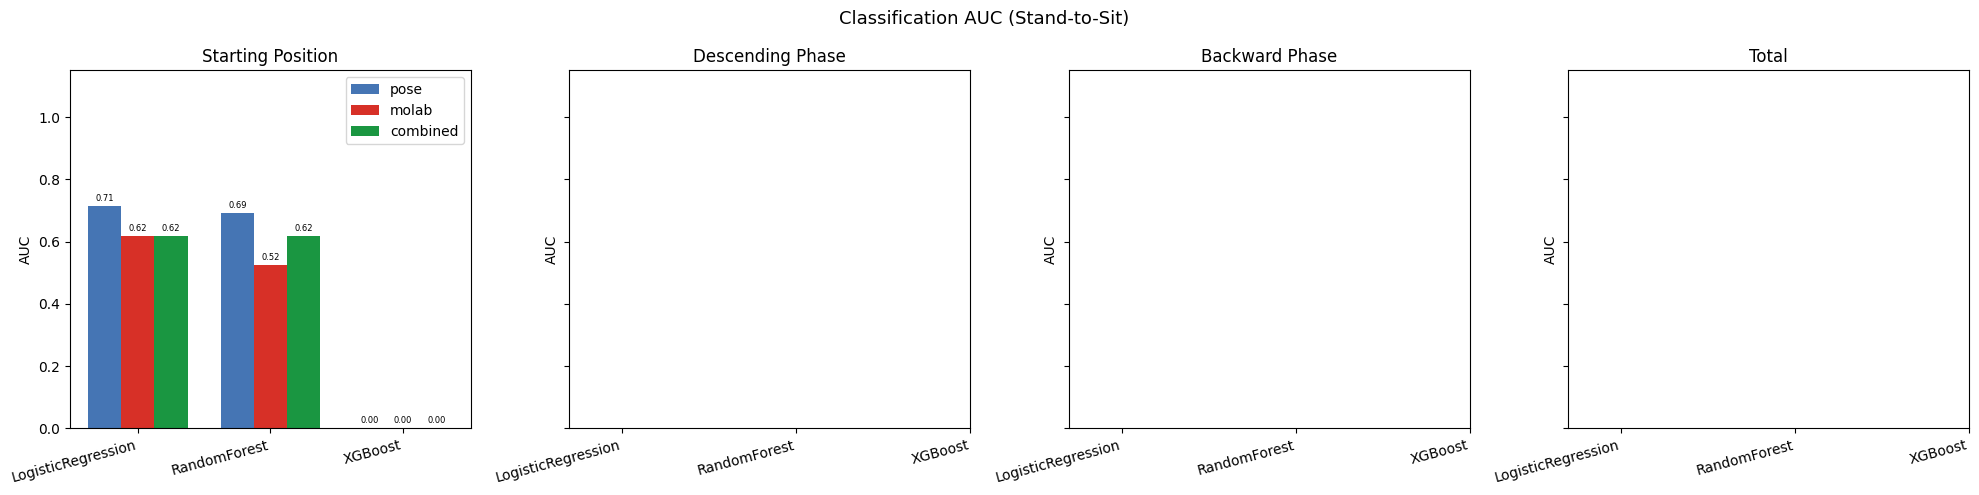

In [15]:
PHASE_LABELS_DOWN_CLS = {
    'utg':   'Starting Position',
    'ned':   'Descending Phase',
    'bak':   'Backward Phase',
    'total': 'Total',
}

COLORS_D = {'pose': '#4575b4', 'molab': '#d73027', 'combined': '#1a9641'}
PHASE_ORDER_DOWN_CLS = list(phase_dfs_down_cls.keys())

for metric in ['Accuracy', 'F1', 'AUC']:
    fig, axes = plt.subplots(1, len(PHASE_ORDER_DOWN_CLS), figsize=(20, 5), sharey=True)
    fig.suptitle(f'Classification {metric} (Stand-to-Sit)', fontsize=13)
    for ax, phase in zip(axes, PHASE_ORDER_DOWN_CLS):
        sub = eval_df_down_cls[eval_df_down_cls['phase'] == phase]
        x = np.arange(len(MODEL_ORDER))
        width = 0.25
        for i, fs in enumerate(FEATURE_SETS):
            vals = []
            for m in MODEL_ORDER:
                mask = (sub['model'] == m) & (sub['feature_set'] == fs)
                v    = sub[mask][metric].values
                vals.append(v[0] if len(v) else np.nan)
            bars = ax.bar(x + i * width, vals, width, label=fs, color=COLORS_D[fs])
            for bar, val in zip(bars, vals):
                if not np.isnan(val):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f'{val:.2f}', ha='center', va='bottom', fontsize=6)
        ax.set_title(PHASE_LABELS_DOWN_CLS[phase])
        ax.set_xticks(x + width)
        ax.set_xticklabels(MODEL_ORDER, rotation=15, ha='right')
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR_DOWN_CLS / f'classification_{metric.lower()}_bar.png', dpi=150)
    plt.show()


In [16]:
mcnemar_rows_d = []

model_pairs = [
    ('LogisticRegression', 'RandomForest'),
    ('LogisticRegression', 'XGBoost'),
    ('RandomForest',       'XGBoost'),
]

for phase in eval_df_down_cls['phase'].unique():
    for fs in FEATURE_SETS:
        for m1, m2 in model_pairs:
            r1 = next(r for r in loocv_results_down_cls
                      if r['phase'] == phase and r['model'] == m1 and r['feature_set'] == fs)
            r2 = next(r for r in loocv_results_down_cls
                      if r['phase'] == phase and r['model'] == m2 and r['feature_set'] == fs)
            yt = np.array(r1['y_true'])
            p1 = np.array(r1['y_pred'])
            p2 = np.array(r2['y_pred'])
            b = np.sum((p1 == yt) & (p2 != yt))
            c = np.sum((p1 != yt) & (p2 == yt))
            table = [[np.sum((p1 == yt) & (p2 == yt)), b],
                     [c, np.sum((p1 != yt) & (p2 != yt))]]
            result = mcnemar(table, exact=True)
            mcnemar_rows_d.append({
                'phase':       phase,
                'feature_set': fs,
                'model_1':     m1,
                'model_2':     m2,
                'b':           b,
                'c':           c,
                'p_value':     result.pvalue,
                'significant': result.pvalue < 0.05,
            })

mcnemar_df_d = pd.DataFrame(mcnemar_rows_d)
mcnemar_df_d.to_csv(OUT_DIR_DOWN_CLS / 'mcnemar_results.csv', index=False)

print(mcnemar_df_d[['phase','feature_set','model_1','model_2','p_value','significant']].to_string(index=False))


phase feature_set            model_1      model_2  p_value  significant
  utg        pose LogisticRegression RandomForest      1.0        False
  utg        pose LogisticRegression      XGBoost      1.0        False
  utg        pose       RandomForest      XGBoost      1.0        False
  utg       molab LogisticRegression RandomForest      1.0        False
  utg       molab LogisticRegression      XGBoost      0.5        False
  utg       molab       RandomForest      XGBoost      0.5        False
  utg    combined LogisticRegression RandomForest      1.0        False
  utg    combined LogisticRegression      XGBoost      1.0        False
  utg    combined       RandomForest      XGBoost      1.0        False
  ned        pose LogisticRegression RandomForest      1.0        False
  ned        pose LogisticRegression      XGBoost      1.0        False
  ned        pose       RandomForest      XGBoost      1.0        False
  ned       molab LogisticRegression RandomForest      1.0      

McNemar test:
- all `p > 0.05`
- no pairwise comparison is statistically significant
- `Total` still shows the clearest descriptive differences

So the observed gaps may still be due to the small dataset.

In [17]:
rows_pv_d = []
for r in loocv_results_down_cls:
    for vid, yt, yp in zip(r['videos'], r['y_true'], r['y_pred']):
        rows_pv_d.append({
            'phase':       r['phase'],
            'model':       r['model'],
            'feature_set': r['feature_set'],
            'video':       vid,
            'y_true':      yt,
            'y_pred':      yp,
        })

per_video_df_d = pd.DataFrame(rows_pv_d)
per_video_df_d.to_csv(OUT_DIR_DOWN_CLS / 'per_video_predictions.csv', index=False)

for phase in eval_df_down_cls['phase'].unique():
    print(f"\n{'='*65}")
    print(f" Phase: {phase}")
    print(f"{'='*65}")
    for model in MODEL_ORDER:
        sub   = per_video_df_d[(per_video_df_d['phase'] == phase) & (per_video_df_d['model'] == model)]
        pose  = sub[sub['feature_set'] == 'pose'].set_index('video')[['y_true','y_pred']].rename(columns={'y_pred':'pose_pred'})
        molab = sub[sub['feature_set'] == 'molab'][['video','y_pred']].set_index('video').rename(columns={'y_pred':'molab_pred'})

        compare = pose.join(molab)
        compare['pose_error']  = compare['y_true'] != compare['pose_pred']
        compare['molab_error'] = compare['y_true'] != compare['molab_pred']

        diff = compare[compare['pose_error'] != compare['molab_error']]
        if diff.empty:
            continue

        print(f"\n  Model: {model}")
        print(f"  {'-'*55}")
        print(f"  {'Video':<8} {'True':>6} {'Pose':>8} {'MoLab':>8} {'Pose err':>10} {'MoLab err':>10}")
        print(f"  {'-'*55}")
        for vid, row in diff.iterrows():
            pose_err  = 'FP' if (row.pose_error  and row.pose_pred  > row.y_true) else ('FN' if row.pose_error  else '-')
            molab_err = 'FP' if (row.molab_error and row.molab_pred > row.y_true) else ('FN' if row.molab_error else '-')
            print(f"  {str(vid):<8} {int(row.y_true):>6} {int(row.pose_pred):>8} {int(row.molab_pred):>8} {pose_err:>10} {molab_err:>10}")
        print(f"  {'-'*55}")



 Phase: utg

  Model: LogisticRegression
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  059           1        1        0          -         FN
  074           0        0        1          -         FP
  -------------------------------------------------------

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  059           1        1        0          -         FN
  -------------------------------------------------------

 Phase: ned

  Model: RandomForest
  -------------------------------------------------------
  Video      True     Pose    MoLab   Pose err  MoLab err
  -------------------------------------------------------
  047           0        0        1          -         FP
  ---------------------------

Error comparison:
- `MoLab` makes several false negatives in `Utgångsposition`, `Rörelsestart`, and `Rörelseutförande`
- `Pose` makes fewer mistakes overall, but some false negatives remain
- a small number of videos drive most of the errors


In [18]:
champion_rows_d = []
for phase in eval_df_down_cls['phase'].unique():
    for fs in FEATURE_SETS:
        sub  = eval_df_down_cls[(eval_df_down_cls['phase'] == phase) & (eval_df_down_cls['feature_set'] == fs)]
        if sub['AUC'].notna().any():
            best = sub.loc[sub['AUC'].idxmax()]
        else:
            best = sub.loc[sub['Accuracy'].idxmax()]
        champion_rows_d.append({
            'phase':       phase,
            'feature_set': fs,
            'model':       best['model'],
            'Accuracy':    round(best['Accuracy'], 3),
            'F1':          round(best['F1'],       3),
            'AUC':         round(best['AUC'], 3) if pd.notna(best['AUC']) else float('nan'),
        })

champion_df_down = pd.DataFrame(champion_rows_d)
champion_df_down.to_csv(OUT_DIR_DOWN_CLS / 'champion_models.csv', index=False)
print(champion_df_down.to_string(index=False))


phase feature_set              model  Accuracy    F1   AUC
  utg        pose LogisticRegression       0.7 0.800 0.714
  utg       molab LogisticRegression       0.5 0.667 0.619
  utg    combined LogisticRegression       0.6 0.714 0.619
  ned        pose LogisticRegression       1.0   NaN   NaN
  ned       molab LogisticRegression       1.0   NaN   NaN
  ned    combined LogisticRegression       1.0   NaN   NaN
  bak        pose LogisticRegression       1.0 1.000   NaN
  bak       molab LogisticRegression       1.0 1.000   NaN
  bak    combined LogisticRegression       1.0 1.000   NaN
total        pose LogisticRegression       1.0 1.000   NaN
total       molab       RandomForest       1.0 1.000   NaN
total    combined       RandomForest       1.0 1.000   NaN


- `LogisticRegression` is best in `9 / 12` combinations
- `RandomForest` leads for `Pose / Utgångsposition`, `MoLab / Rörelsestart`, and `Pose / Total`

So `LogisticRegression` is still the main stand-to-sit winner.